# Insurance Cost Analysis

**Submitted by:** Xiji Hang (MC646933).

**CISC7204 Data Science and Data Visualization — Assignment 01**

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131). This laboratory is joint work throughout.

The required analysis follows the supplied course notebook. A separate extension examines the agreed research question. Reported results below are produced by the code in this notebook.

# **Practice Project: Insurance Cost Analysis**

Estimated time needed: **75** minutes

In this project, you have to perform analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 
In this project, you will:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 
 


In [1]:
# Figures use 300 DPI for readable high-resolution exports.
# Regression plots use seed=1 only for reproducible bootstrap confidence bands.
from pathlib import Path
import json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
    GroupKFold, GridSearchCV)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import sklearn

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (7.2, 4.0), "figure.dpi": 300,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('medical_insurance_dataset.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
RESULTS = OUTPUT_ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__}")


Python 3.14.6 | pandas 3.0.3 | scikit-learn 1.9.0


In [2]:
path = DATA / "medical_insurance_dataset.csv"
print(path.name)

medical_insurance_dataset.csv


Source: [IBM course insurance CSV](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv), retrieved 15 September 2026. The course notebook codes smoking as 0/1; the actual CSV confirms these values. The Moodle overview uses a different coding description, so the figures follow the notebook data.

# Task 1 : Import the dataset

Import the dataset into a `pandas` dataframe. Note that there are currently no headers in the CSV file. 

Print the first 10 rows of the dataframe to confirm successful loading.


In [3]:
df = pd.read_csv(path, header=None)
display(df.head(10))

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.9240
1,18,2,33.770,1,0,4,1725.5523
2,28,2,33.000,3,0,4,4449.4620
3,33,2,22.705,0,0,1,21984.4706
4,32,2,28.880,0,0,1,3866.8552
5,31,1,25.740,0,?,4,3756.6216
6,46,1,33.440,1,0,4,8240.5896
7,37,1,27.740,3,0,1,7281.5056
8,37,2,29.830,2,0,2,6406.4107
9,60,1,25.840,0,0,1,28923.1369


Add the headers to the dataframe, as mentioned in the project scenario. 


In [4]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers
print(df.shape)
print(df.columns.tolist())

(2772, 7)
['age', 'gender', 'bmi', 'no_of_children', 'smoker', 'region', 'charges']


Now, replace the '?' entries with 'NaN' values.


In [5]:
df = df.replace("?", np.nan)
display(df.isna().sum().rename("Missing entries").to_frame())

,Missing entries
age,4
gender,0
bmi,0
no_of_children,0
smoker,7
region,0
charges,0


# Task 2 : Data Wrangling


Use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   str    
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   str    
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 160.5 KB


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.


In [7]:
df = df.apply(pd.to_numeric)
age_mean = df["age"].mean()
smoker_mode = df["smoker"].mode().iloc[0]
df["age"] = df["age"].fillna(age_mean).astype(int)
df["smoker"] = df["smoker"].fillna(smoker_mode).astype(int)
print(f"Mean age before integer conversion: {age_mean:.4f}; smoker mode: {smoker_mode:g}")
df.info()

Mean age before integer conversion: 39.1098; smoker mode: 0
<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


The prescribed age conversion truncates the fractional imputed mean. Direct column assignment is used for compatibility with pandas 3. The extension retains fractional imputed ages and estimates imputation values within training folds.

Also note, that the `charges` column has values which are more than 2 decimal places long. Update the `charges` column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.


In [8]:
df["charges"] = df["charges"].round(2)
display(df.head())

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92
1,18,2,33.770,1,0,4,1725.55
2,28,2,33.000,3,0,4,4449.46
3,33,2,22.705,0,0,1,21984.47
4,32,2,28.880,0,0,1,3866.86


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 


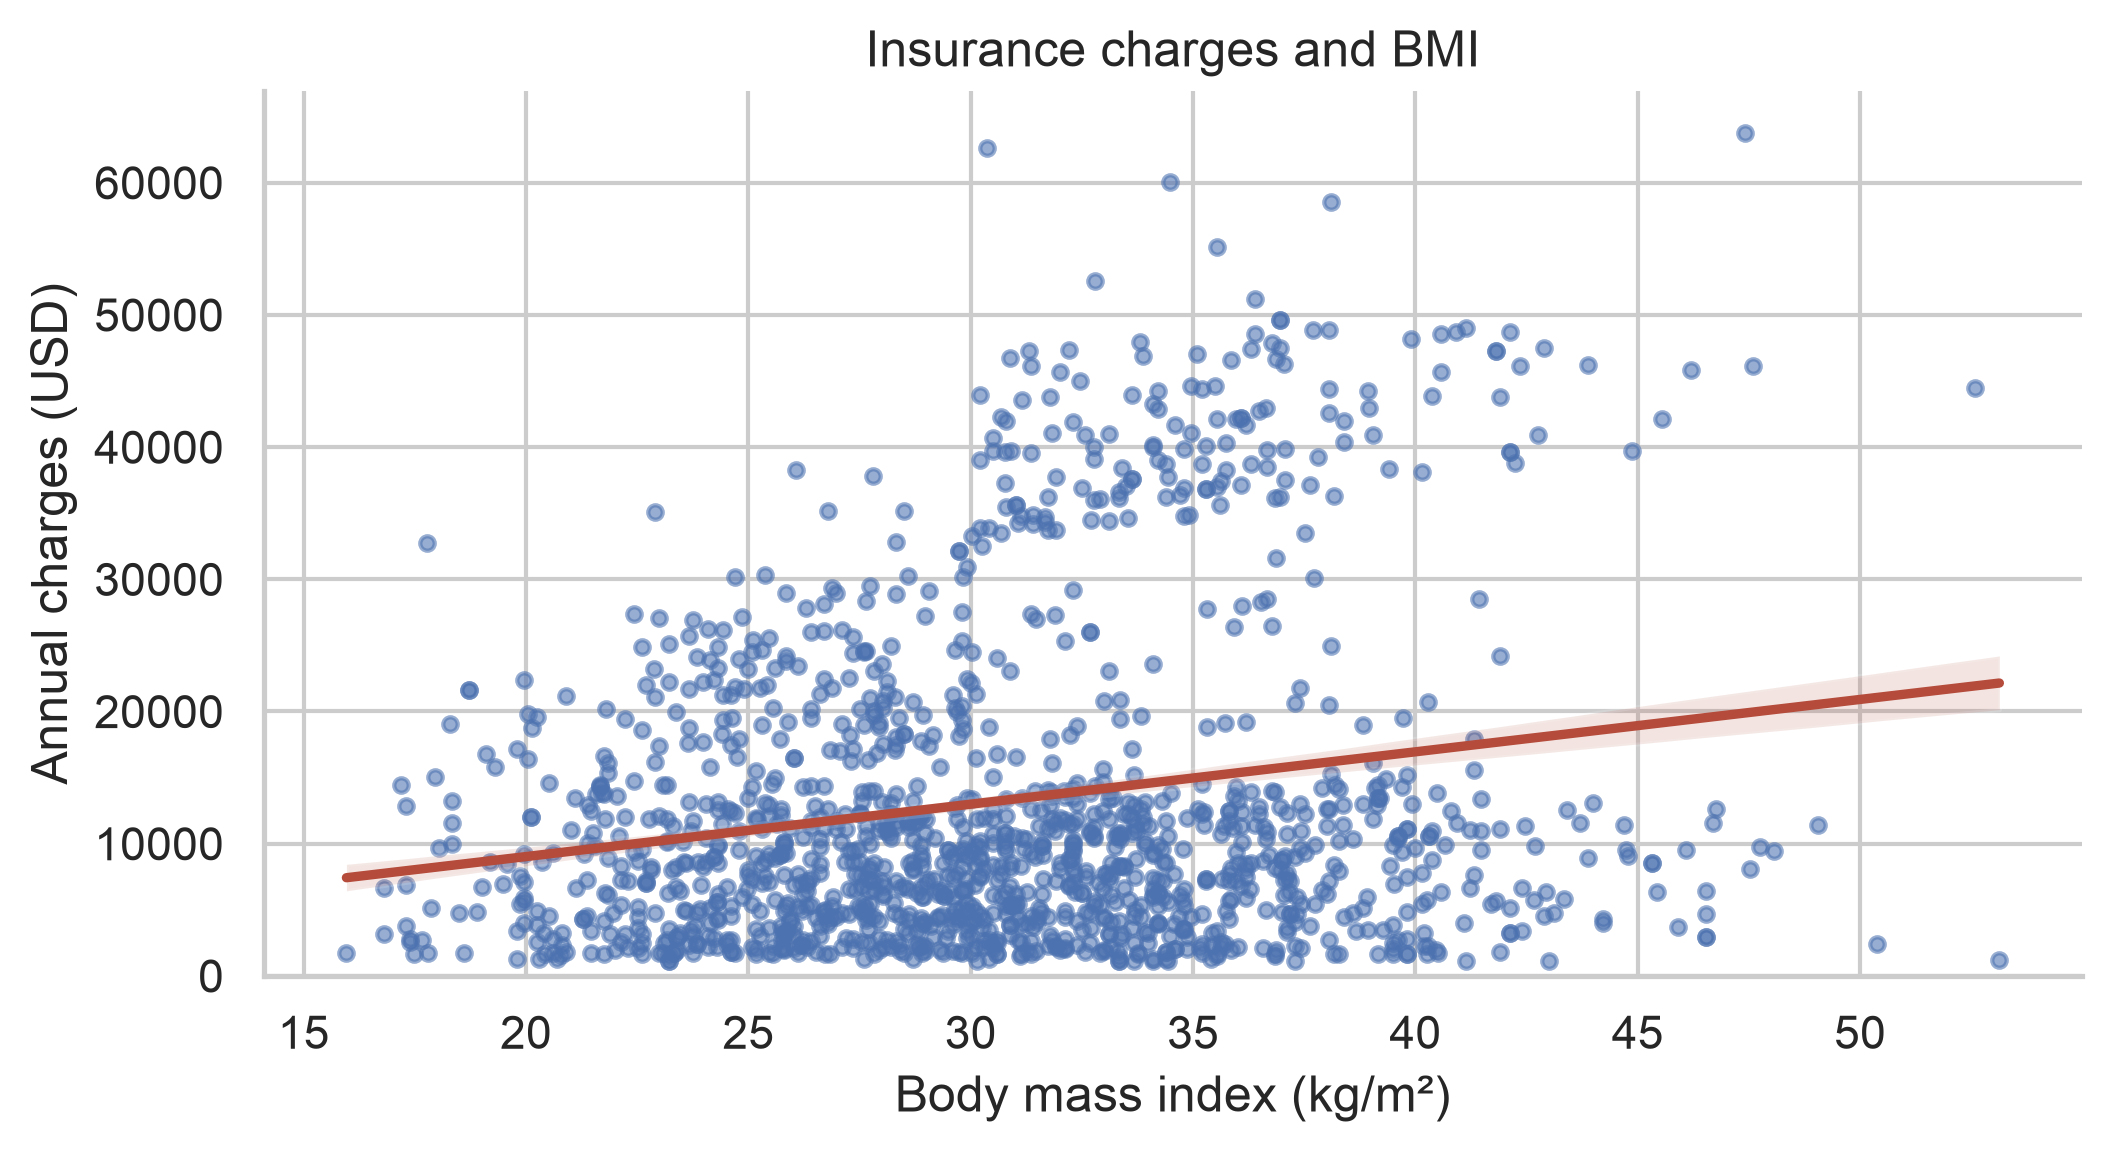

In [9]:
sns.regplot(seed=1, data=df, x="bmi", y="charges", line_kws={"color":"#b54b3a"},
            scatter_kws={"s":12,"alpha":0.35})
plt.xlabel("Body mass index (kg/m²)"); plt.ylabel("Annual charges (USD)")
plt.title("Insurance charges and BMI"); plt.ylim(bottom=0)
plt.tight_layout(); plt.show()

Implement the box plot for `charges` with respect to `smoker`.


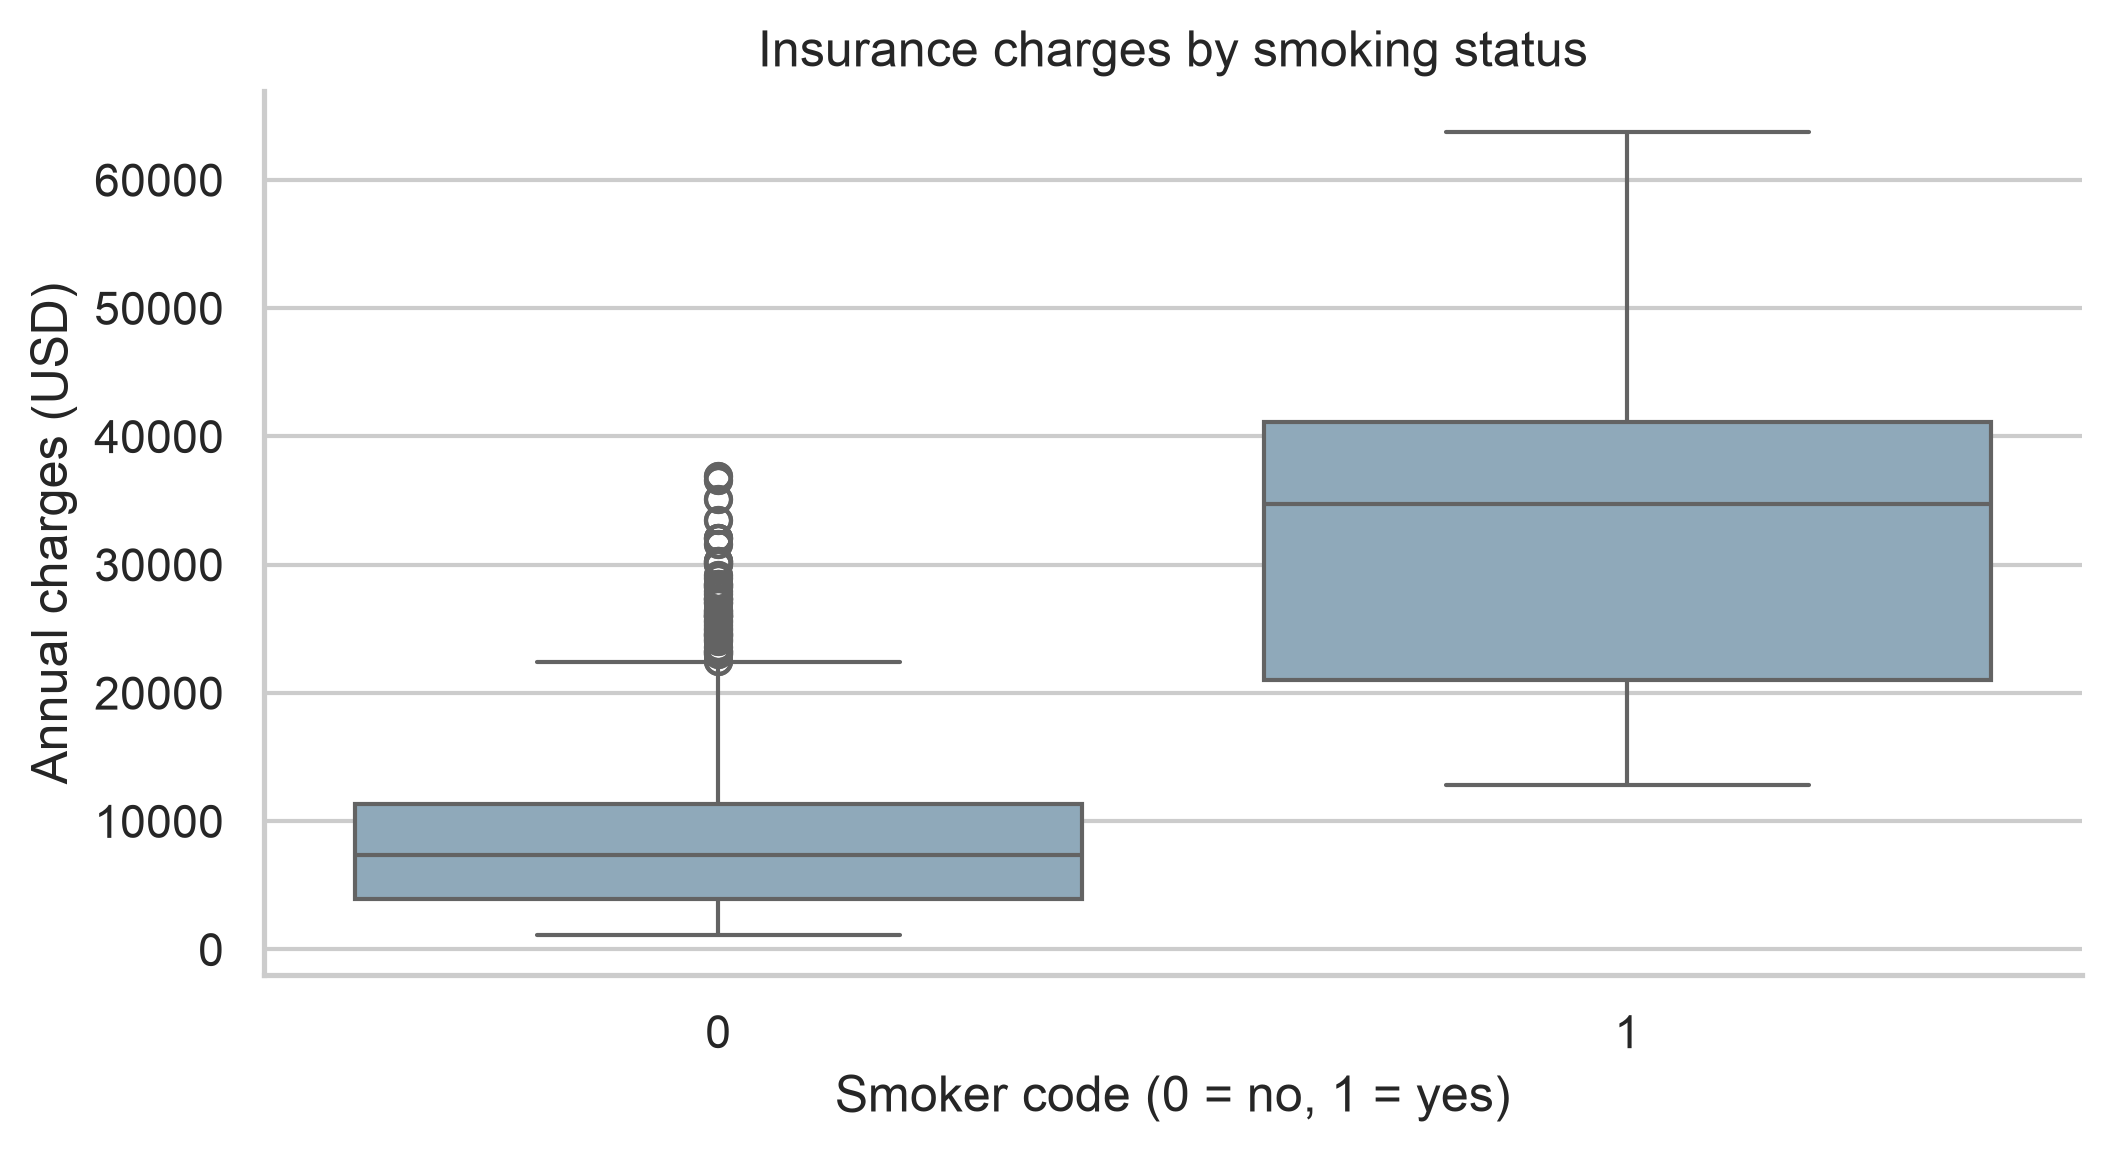

In [10]:
sns.boxplot(data=df, x="smoker", y="charges", color="#88abc1")
plt.xlabel("Smoker code (0 = no, 1 = yes)"); plt.ylabel("Annual charges (USD)")
plt.title("Insurance charges by smoking status")
plt.tight_layout(); plt.show()

Print the correlation matrix for the dataset.


In [11]:
display(df.corr().round(3))

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000,-0.026,0.113,0.038,-0.023,-0.007,0.299
gender,-0.026,1.000,0.043,0.016,0.082,0.022,0.063
bmi,0.113,0.043,1.000,-0.001,0.011,0.271,0.200
no_of_children,0.038,0.016,-0.001,1.000,0.006,-0.026,0.066
smoker,-0.023,0.082,0.011,0.006,1.000,0.054,0.789
region,-0.007,0.022,0.271,-0.026,0.054,1.000,0.054
charges,0.299,0.063,0.200,0.066,0.789,0.054,1.000


Smoking status has the strongest observed correlation with charges (r = 0.789), followed by age (0.299) and BMI (0.200). Pearson coefficients for gender and region codes depend on their encoding and should not be read as effects of increasing a category number. The plots describe associations, not causal effects of smoking or BMI.

# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [12]:
Y = df["charges"]
X = df[["smoker"]]
lm = LinearRegression().fit(X,Y)
required_scores = {"Smoker only": lm.score(X,Y)}
print(f"Smoker-only in-sample R²: {required_scores['Smoker only']:.4f}")

Smoker-only in-sample R²: 0.6222


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [13]:
features = ["age", "gender", "bmi", "no_of_children", "smoker", "region"]
Z = df[features]
lm.fit(Z,Y)
required_scores["Multiple linear"] = lm.score(Z,Y)
print(f"Multiple-linear in-sample R²: {required_scores['Multiple linear']:.4f}")

Multiple-linear in-sample R²: 0.7504


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [14]:
pipe = Pipeline([("scale",StandardScaler()),
                 ("polynomial",PolynomialFeatures(include_bias=False)),
                 ("model",LinearRegression())])
pipe.fit(Z,Y)
required_scores["Polynomial pipeline"] = r2_score(Y,pipe.predict(Z))
display(pd.Series(required_scores,name="In-sample R²").to_frame())

,In-sample R²
Smoker only,0.6222
Multiple linear,0.7504
Polynomial pipeline,0.8453


These three scores describe fit to the same records used for training. More flexible polynomial terms can raise in-sample R² without establishing better performance on new records.

# Task 5 : Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [15]:
x_train,x_test,y_train,y_test = train_test_split(Z,Y,test_size=0.2,random_state=1)
print(f"Training records: {len(x_train)}; test records: {len(x_test)}")

Training records: 2217; test records: 555


Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [16]:
ridge = Ridge(alpha=0.1).fit(x_train,y_train)
ridge_test = r2_score(y_test,ridge.predict(x_test))
print(f"Ridge alpha=0.1, test R²: {ridge_test:.4f}")

Ridge alpha=0.1, test R²: 0.6761


Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the $ R^2 $ score for the testing subset.


In [17]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
ridge_poly = Ridge(alpha=0.1).fit(x_train_pr,y_train)
ridge_poly_test = r2_score(y_test,ridge_poly.predict(x_test_pr))
print(f"Degree-2 Ridge alpha=0.1, test R²: {ridge_poly_test:.4f}")

Degree-2 Ridge alpha=0.1, test R²: 0.7836


The required demonstration imputes on the full dataset before splitting. Its row-level test scores also include a risk from repeated source records. The extension below uses raw data, grouped splitting and training-fold preprocessing to make a more defensible comparison.

## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|


<h3> Copyright © 2023 IBM Corporation. All rights reserved. </h3>


## Extension — Original versus log charges

We compare two otherwise identical degree-2 Ridge pipelines. One fits charges directly; the other fits log charges. Both are selected using dollar-scale validation RMSE and evaluated on the same held-out profiles. The extension changes the evaluation protocol as well as encoding relative to the teaching example, so its scores should be compared with each other rather than attributed solely to a single change from Task 5.


In [18]:
raw = pd.read_csv(path, header=None, names=headers, na_values="?")
raw = raw.apply(pd.to_numeric)
assert raw["charges"].notna().all() and raw["charges"].gt(0).all()
duplicate_rows = int(raw.duplicated().sum())
X_ext, y_ext = raw[features], raw["charges"]
# Identical predictor profiles stay together; the target does not define groups.
groups = pd.util.hash_pandas_object(X_ext, index=False).to_numpy()
split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
train_idx, test_idx = next(split.split(X_ext,y_ext,groups))
assert not set(groups[train_idx]) & set(groups[test_idx])
print(f"Records: {len(raw)}; exact duplicate rows: {duplicate_rows}")
print(f"Distinct predictor profiles: {len(np.unique(groups))}")
print(f"Training/test records: {len(train_idx)}/{len(test_idx)}")
print(f"Training/test profiles: {len(np.unique(groups[train_idx]))}/{len(np.unique(groups[test_idx]))}")
display(raw.isna().sum().rename("Missing entries").to_frame())

Records: 2772; exact duplicate rows: 1424
Distinct predictor profiles: 1346
Training/test records: 2220/552
Training/test profiles: 1076/270


,Missing entries
age,4
gender,0
bmi,0
no_of_children,0
smoker,7
region,0
charges,0


The source has no person identifier. Grouping identical observed predictor profiles prevents exact profile overlap; it cannot prove that all remaining people are independent, particularly where missing values alter a profile. All source rows are retained, so record-level metrics retain the source dataset's repetition weights. The 20% split refers to profile groups rather than exactly 20% of rows.

In [19]:
numeric = ["age","bmi","no_of_children"]
categorical = ["gender","smoker","region"]
def insurance_pipeline():
    prep = ColumnTransformer([
        ("numeric",SimpleImputer(strategy="mean"),numeric),
        ("category",Pipeline([
            ("impute",SimpleImputer(strategy="most_frequent")),
            ("encode",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
        ]),categorical)])
    return Pipeline([("prepare",prep),
                     ("poly",PolynomialFeatures(degree=2,include_bias=False)),
                     ("scale",StandardScaler()),("ridge",Ridge())])

folds = list(GroupKFold(n_splits=5).split(
    X_ext.iloc[train_idx], y_ext.iloc[train_idx], groups[train_idx]))
alpha_grid = [0.01,0.1,1,10,100]
searches = {}
for target_scale in ["Original charges","Log charges"]:
    model = TransformedTargetRegressor(regressor=insurance_pipeline(),
        func=np.log if target_scale=="Log charges" else None,
        inverse_func=np.exp if target_scale=="Log charges" else None)
    search = GridSearchCV(model,{"regressor__ridge__alpha":alpha_grid},
        scoring="neg_root_mean_squared_error",cv=folds)
    search.fit(X_ext.iloc[train_idx],y_ext.iloc[train_idx])
    searches[target_scale]=search
display(pd.DataFrame([
    {"Target":name,"Selected alpha":s.best_params_["regressor__ridge__alpha"],
     "CV RMSE (USD)":-s.best_score_}
    for name,s in searches.items()]).set_index("Target"))

,Selected alpha,CV RMSE (USD)
Target,,
Original charges,1.00,4962.3953
Log charges,0.01,5202.9166


In [20]:
ext_rows=[]; ext_predictions={}
for name,search in searches.items():
    pred=search.predict(X_ext.iloc[test_idx])
    assert np.isfinite(pred).all()
    ext_predictions[name]=pred
    ext_rows.append({"Target":name,"R²":r2_score(y_ext.iloc[test_idx],pred),
        "MAE (USD)":mean_absolute_error(y_ext.iloc[test_idx],pred),
        "RMSE (USD)":mean_squared_error(y_ext.iloc[test_idx],pred)**0.5,
        "Negative predictions":int((pred<0).sum())})
insurance_results=pd.DataFrame(ext_rows).set_index("Target")
display(insurance_results.round(3))
insurance_results.to_csv(RESULTS/"insurance_extension_metrics.csv")

,R²,MAE (USD),RMSE (USD),Negative predictions
Target,,,,
Original charges,0.802,2771.083,4692.247,2
Log charges,0.780,2461.719,4943.388,0


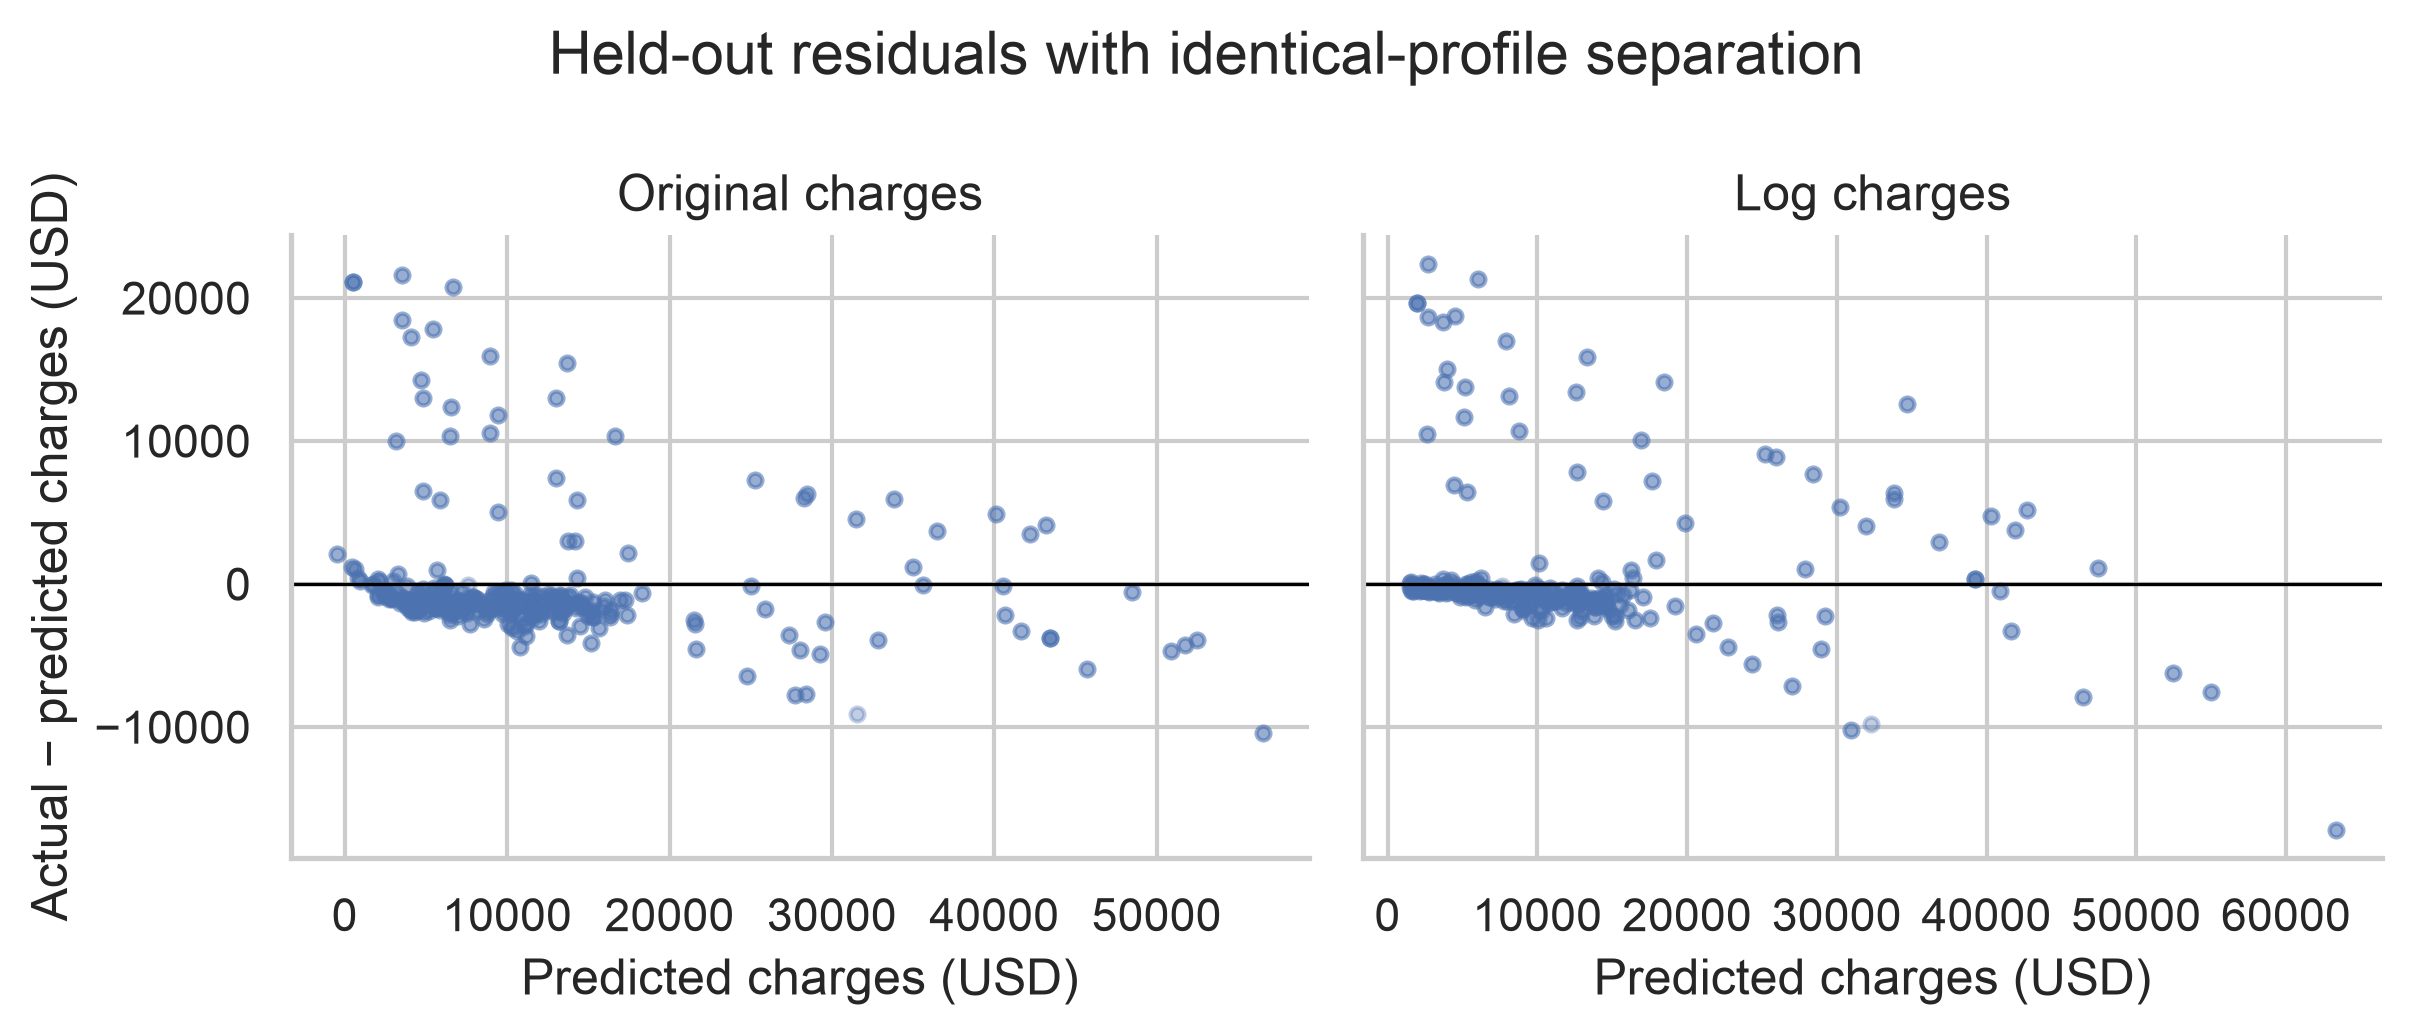

In [21]:
fig,axes=plt.subplots(1,2,figsize=(8.2,3.5),sharey=True)
for ax,(name,pred) in zip(axes,ext_predictions.items()):
    ax.scatter(pred,y_ext.iloc[test_idx]-pred,s=11,alpha=.35)
    ax.axhline(0,color="black",linewidth=.8)
    ax.set(title=name,xlabel="Predicted charges (USD)")
axes[0].set_ylabel("Actual − predicted charges (USD)")
fig.suptitle("Held-out residuals with identical-profile separation")
fig.tight_layout();plt.show()

In [22]:
a=insurance_results.loc["Original charges"]; b=insurance_results.loc["Log charges"]
delta=b["RMSE (USD)"]-a["RMSE (USD)"]
display(Markdown(
    f"On the held-out profile groups, the log-target model has RMSE **USD {b['RMSE (USD)']:,.0f}** "
    f"versus **USD {a['RMSE (USD)']:,.0f}** for the original-target model, a difference of "
    f"**USD {delta:,.0f}** (log minus original). Its MAE is **USD {b['MAE (USD)']:,.0f}**, "
    f"compared with **USD {a['MAE (USD)']:,.0f}**. The two error measures should be considered "
    "together: RMSE gives more weight to large errors. These are results for one grouped holdout, "
    "not evidence of a universal advantage for either target scale."))

On the held-out profile groups, the log-target model has RMSE **USD 4,943** versus **USD 4,692** for the original-target model, a difference of **USD 251** (log minus original). Its MAE is **USD 2,462**, compared with **USD 2,771**. The two error measures should be considered together: RMSE gives more weight to large errors. These are results for one grouped holdout, not evidence of a universal advantage for either target scale.

Exponentiating a fitted log response does not automatically recover the original-scale conditional mean. No smearing correction or clipping is applied; both choices would change the prespecified comparison. This historical, modified educational dataset cannot establish performance for a different insurer or population.

## Acknowledgement

The laboratory template and teaching examples are adapted from the IBM Skills Network materials supplied through CISC7204. [OpenAI Codex](https://openai.com/codex/) assisted with code implementation, compatibility fixes, debugging and the wording of explanations. Numerical results were generated by executing this notebook; both collaborators are responsible for reviewing the work before submission.
